=== Downside-Vol Targeting Backtest (semi-variance) + neg_ann_vol + Smoothed Sortino risk-off ===
Source: MT5 export | Symbol: MT5_FILE
Requested analysis window: 2000-01-01 -> 2026-03-26
Warmup start used: 1998-12-17 | Warmup bars target: 272
Rows used for full calc: 4190 | Rows used for final analysis: 3937
First valid input date: 2010-12-22
First actual exposure date: 2010-12-22
Final analysis window: 2010-12-22 -> 2026-02-26
Target vol risk-on/off: 0.2 / 0.1
VolWindows: [21] | Aggregation: MAX | MAR(signal): 0.0
Sortino filter: True | Window=252
Sortino smoothing: True | Method=ema | EMA span=10 | SMA window=10
Risk-off if smoothed Sortino(252)[t-1] <= 0
Risk-off max leverage cap: 1.0
Risk-on max leverage cap: 3.0
Rolling alpha/beta window: 252 days
PointValue: 50.0 | MinLot=1.0, Step=1.0, MaxLot=1e+20
Commission: $4.0/lot/side | Spread: 0.0 pts | Slippage: 0.0 pts
Total costs deducted (analysis window): 15752.00

Regime share (analysis window): {'risk_on': 0.8796037592075184, 'ris

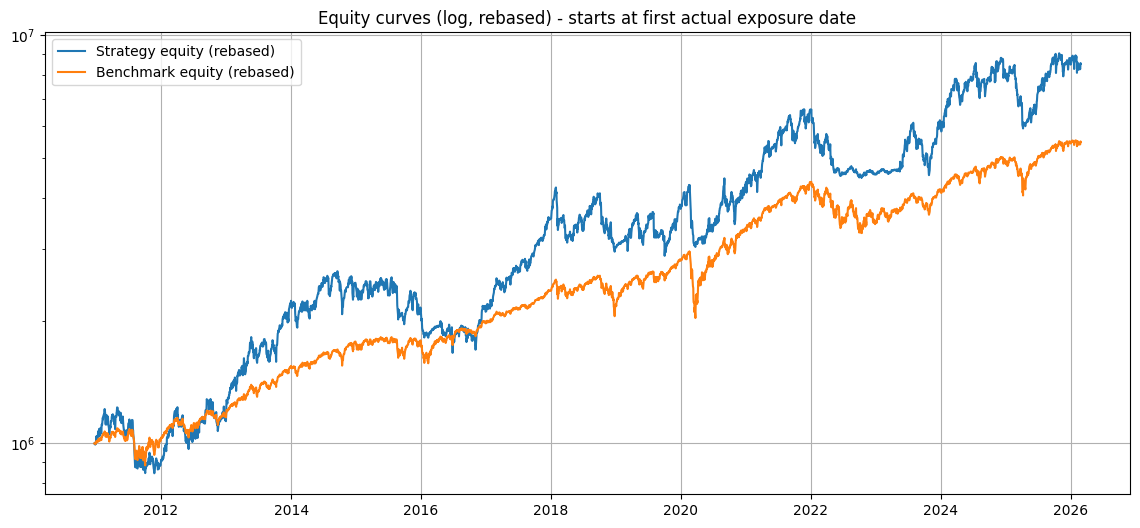

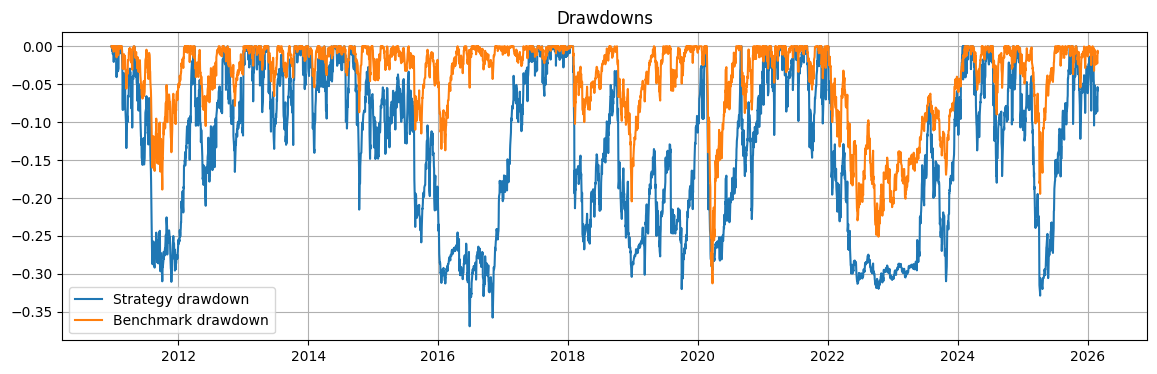

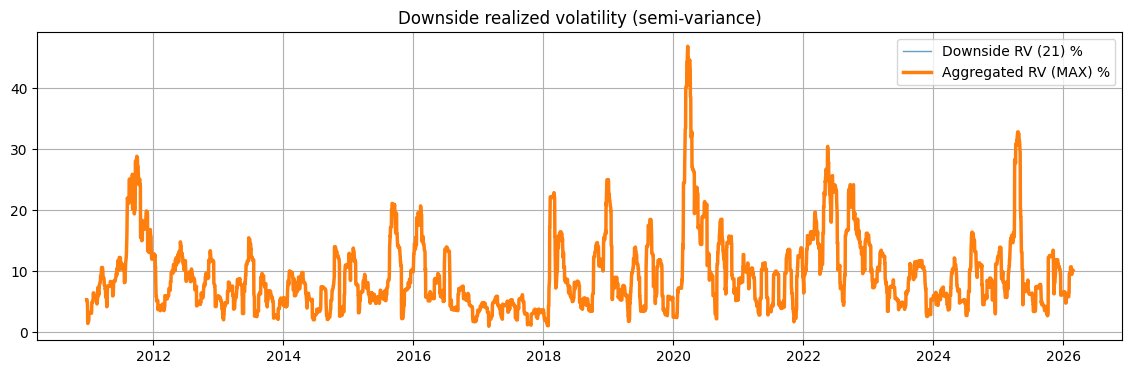

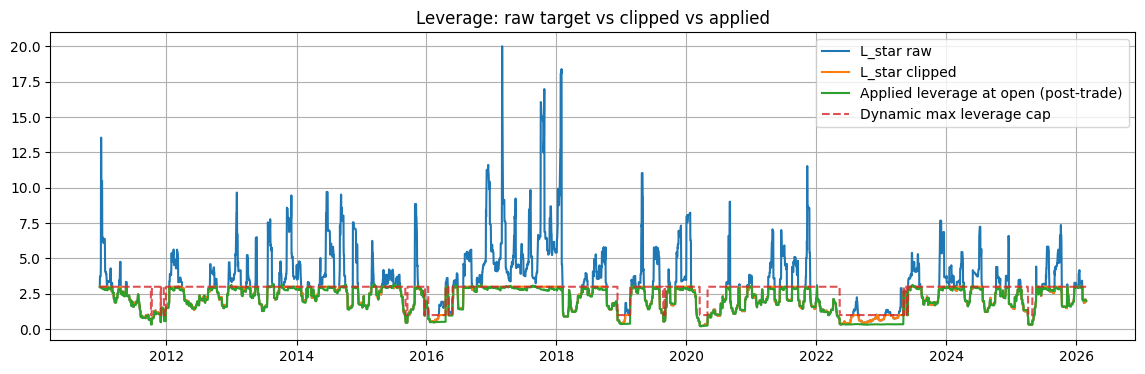

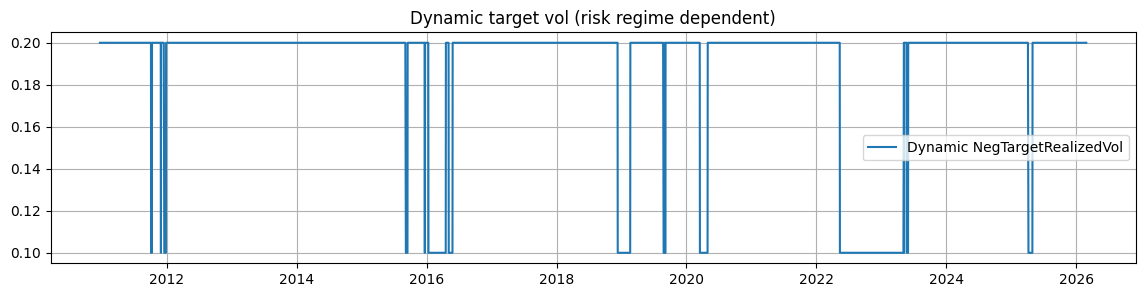

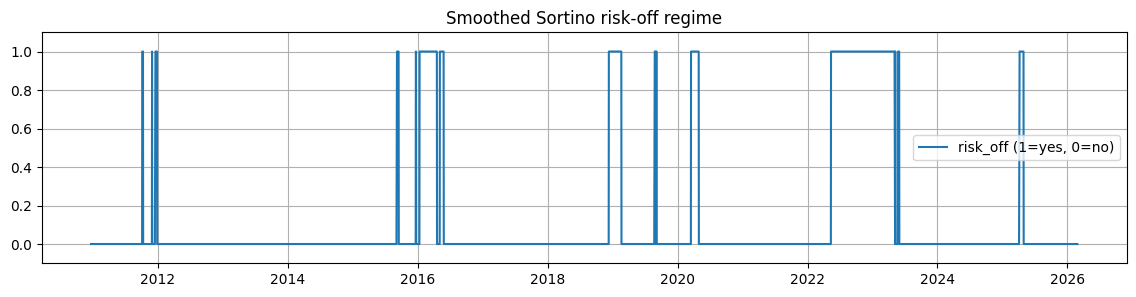

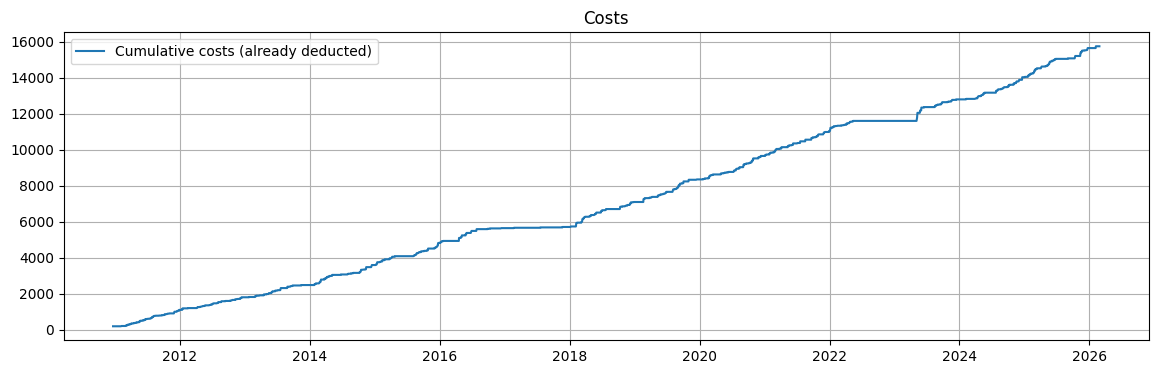

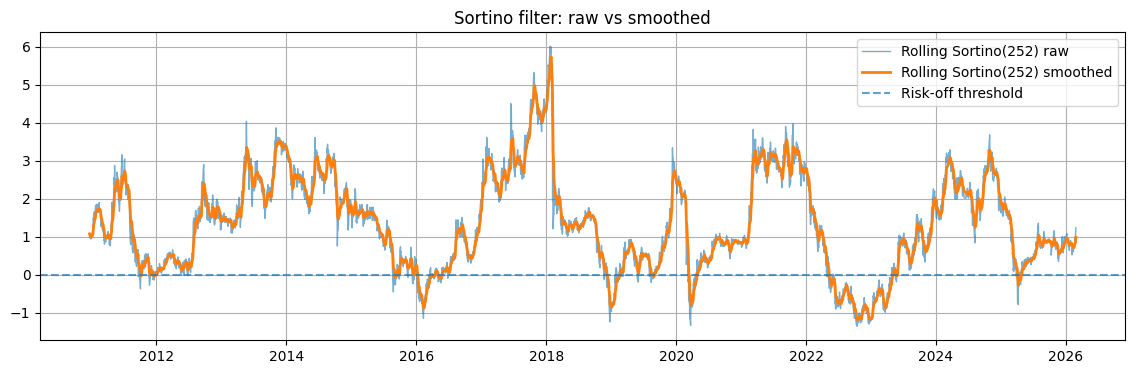

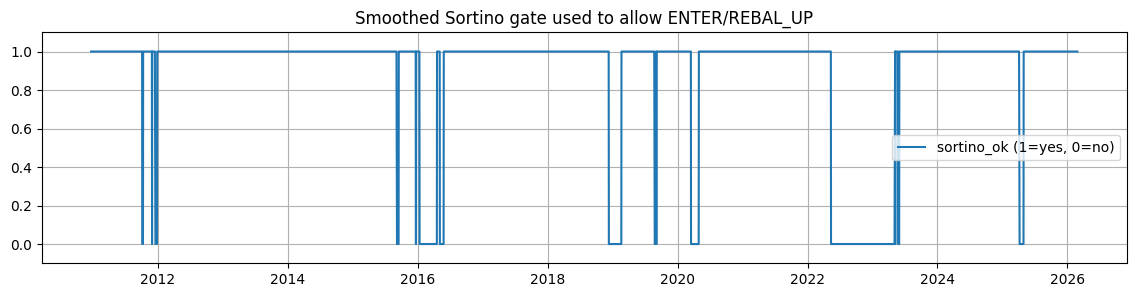

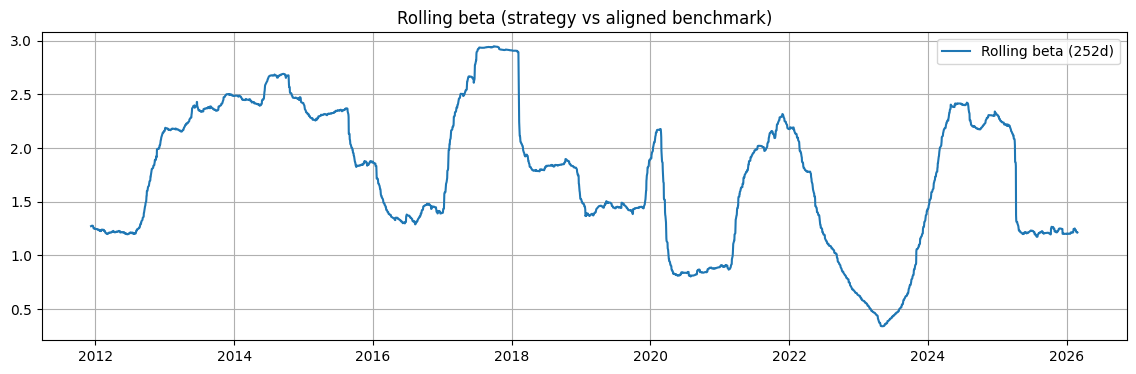

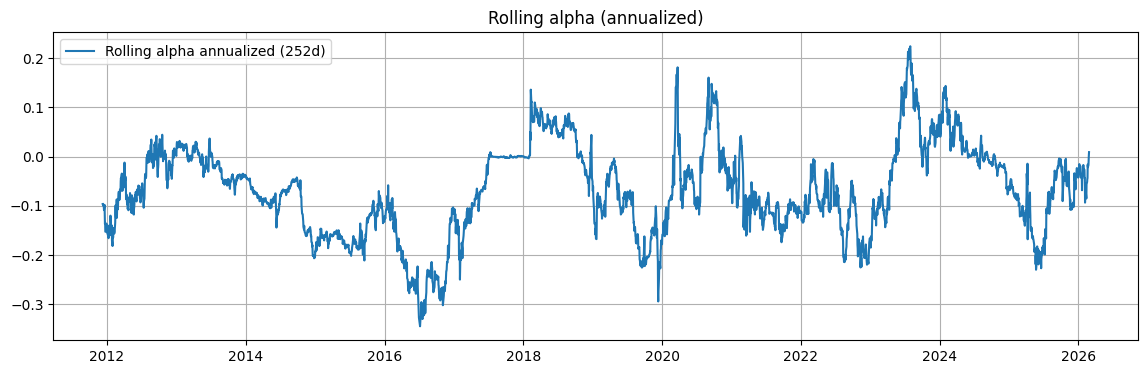


Last 25 trade events:
      date     action  open_mid  NegTarget_dyn  risk_off  max_leverage_dyn  L_star_raw   L_star  lots_before  lots_target  lots_after  deltaLots  chunks  commission  spread_cost  slippage_cost  order_fees  cost_total  L_cur_before  rv1_down_agg  sortino_ok  sortino_252_raw  sortino_252_signal_t1
2025-03-11 REBAL_DOWN   5819.00            0.2     False               3.0    1.365898 1.365898         44.0         32.0        32.0      -12.0      12        48.0          0.0            0.0         0.0        48.0      1.850300      0.146424        True         0.110335               0.785523
2025-04-04 REBAL_DOWN   5563.75            0.2     False               3.0    1.039277 1.039277         32.0         24.0        24.0       -8.0       8        32.0          0.0            0.0         0.0        32.0      1.367367      0.192441        True        -0.740047               0.090359
2025-04-07 REBAL_DOWN   5123.25            0.1      True               1.0    0.353323

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vectorbt as vbt

# =========================================================
# Downside-Vol Targeting Backtest (semi-variance) + neg_ann_vol
# Comparison window starts on the FIRST DATE WITH ACTUAL EXPOSURE
# Plot kept: REBASED LOG EQUITY ONLY
# =========================================================

# ================== Data source switch ==================
USE_YF = False  # set False to load from MT5 CSV/TSV

# ----- Requested analysis window -----
symbol = "ES=F"
start = "2000-01-01"
end   = "2026-03-26"

# ----- MT5 export (if USE_YF=False) -----
csv_path = r"C:\Users\Juanan\Downloads\ES_H_Daily_201001010000_202602260000.csv"
mt5_sep = "\t"

# ================== Inputs ==================
NEG_TARGET_RISK_ON  = 0.20
NEG_TARGET_RISK_OFF = 0.10

VolWindows = [21]
UseMaxAcrossWindows = True
RealizedVolFloor = 0.01
MAR = 0.0

MaxLeverage   = 3.0
MinLeverage   = 0.0
RISK_OFF_MAX_LEVERAGE = 1.0

RebalanceUp   = 0.10
RebalanceDown = 0.10
FlatEps       = 0.0

# ================== Sortino filter ==================
USE_SORTINO_FILTER = True
SORTINO_WINDOW = 252
SORTINO_MAR_ANNUAL = 0.0
BLOCK_SCALE_UP_WHEN_SORTINO_BAD = True

# ================== Sortino smoothing ==================
SMOOTH_SORTINO = True
SORTINO_SMOOTH_METHOD = "ema"   # "ema" or "sma"
SORTINO_SMOOTH_SPAN = 10
SORTINO_SMOOTH_WINDOW = 10

# ================== Rolling alpha/beta ==================
ROLLING_AB_WINDOW = 252
TRADING_DAYS = 252
MAR_EQ_RET = 0.0

# ================== Contract specs ==================
TickSize   = 0.25
TickValue  = 12.5
PointValue = TickValue / TickSize  # 50 USD per 1.00 point

# ================== Volume constraints ==================
MinLot   = 1.0
LotStep  = 1.0
MaxLot   = 99999999999999999999.0

# Chunking
LotsPerChunk = 1.0  # set 0 to disable

# ================== Costs ==================
commission_per_lot_per_side = 4.0
slippage_points             = 0.0
spread_points               = 0.0
per_order_fee               = 0.0

init_cash = 1_000_000.0

# ================== Helpers ==================
def clamp(x: float, lo: float, hi: float) -> float:
    return float(min(max(x, lo), hi))

def is_weekend(ts: pd.Timestamp) -> bool:
    return ts.weekday() >= 5

def make_index_tz_naive(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    if getattr(df.index, "tz", None) is not None:
        df.index = df.index.tz_convert(None)
    return df

def drawdown_from_equity(eq: pd.Series) -> pd.Series:
    peak = eq.cummax()
    return eq / peak - 1.0

def neg_annualized_vol_from_returns(rets: pd.Series, mar: float = 0.0, freq: int = 252) -> float:
    rets = rets.dropna()
    if len(rets) == 0:
        return float("nan")
    d = np.minimum(rets.to_numpy(dtype=float) - float(mar), 0.0)
    return float(np.sqrt(np.mean(d * d)) * np.sqrt(freq))

def perf_stats_from_equity(eq: pd.Series, freq: int = 252, mar_eq_ret: float = 0.0) -> dict:
    eq = eq.dropna()
    if len(eq) < 2:
        return {
            "total_return": np.nan,
            "cagr": np.nan,
            "ann_vol": np.nan,
            "neg_ann_vol": np.nan,
            "sharpe": np.nan,
            "max_dd": np.nan
        }

    rets = eq.pct_change().dropna()
    total_return = float(eq.iloc[-1] / eq.iloc[0] - 1.0)
    years = (len(eq) - 1) / freq
    cagr = float((eq.iloc[-1] / eq.iloc[0]) ** (1 / years) - 1.0) if years > 0 else np.nan

    ann_vol = float(rets.std(ddof=0) * np.sqrt(freq)) if len(rets) > 1 else np.nan
    neg_ann_vol = neg_annualized_vol_from_returns(rets, mar=mar_eq_ret, freq=freq)
    sharpe = float((rets.mean() * freq) / ann_vol) if ann_vol and ann_vol != 0 else np.nan
    max_dd = float(drawdown_from_equity(eq).min())

    return {
        "total_return": total_return,
        "cagr": cagr,
        "ann_vol": ann_vol,
        "neg_ann_vol": neg_ann_vol,
        "sharpe": sharpe,
        "max_dd": max_dd
    }

def profit_metrics_from_equity(eq: pd.Series, init_cash_ref: float) -> dict:
    eq = eq.dropna()
    if len(eq) == 0:
        return {
            "total_net_profit": np.nan,
            "gross_profit": np.nan,
            "gross_loss": np.nan
        }

    pnl = eq.diff().dropna()
    gross_profit = float(pnl[pnl > 0].sum())
    gross_loss = float(-pnl[pnl < 0].sum())
    total_net_profit = float(eq.iloc[-1] - init_cash_ref)

    return {
        "total_net_profit": total_net_profit,
        "gross_profit": gross_profit,
        "gross_loss": gross_loss
    }

def normalize_lots_scalar(lots: float) -> float:
    lots = min(max(lots, 0.0), MaxLot)
    lots = np.floor(lots / LotStep) * LotStep
    if lots < MinLot:
        return 0.0
    return float(lots)

def lots_for_notional_scalar(notional: float, price_mid: float, point_value: float) -> float:
    if notional <= 0.0 or price_mid <= 0.0 or point_value <= 0.0:
        return 0.0
    return normalize_lots_scalar(notional / (price_mid * point_value))

def chunk_plan(delta_lots: float, lots_per_chunk: float) -> list:
    delta_lots = float(delta_lots)
    if abs(delta_lots) < 1e-12:
        return []
    if lots_per_chunk is None or lots_per_chunk <= 0:
        return [delta_lots]

    sign = 1.0 if delta_lots > 0 else -1.0
    remaining = abs(delta_lots)

    chunks = []
    step = max(LotStep, 1e-12)
    chunk_size = max(lots_per_chunk, step)

    while remaining >= step - 1e-12:
        this = min(chunk_size, remaining)
        this = np.floor(this / step) * step
        if this < step - 1e-12:
            break
        chunks.append(sign * float(this))
        remaining -= float(this)

    return chunks

def downside_realized_vol(close_s: pd.Series, window: int, mar: float = 0.0,
                          floor: float = 0.0, ann_factor: float = 252.0) -> pd.Series:
    r = np.log(close_s / close_s.shift(1))
    d = np.minimum(r - mar, 0.0)
    rv_down = d.rolling(window, min_periods=window).apply(
        lambda x: np.sqrt(np.mean(np.square(x))), raw=True
    ) * np.sqrt(ann_factor)
    if floor is not None and floor > 0:
        rv_down = rv_down.clip(lower=floor)
    return rv_down

def rolling_sortino_from_log_returns(close_s: pd.Series, window: int = 252,
                                     mar_annual: float = 0.0, ann_factor: int = 252) -> pd.Series:
    r = np.log(close_s / close_s.shift(1))
    mar_per_bar = float(mar_annual) / float(ann_factor)
    ex_ret = r - mar_per_bar
    downside = np.minimum(ex_ret, 0.0)

    mean_excess_ann = ex_ret.rolling(window, min_periods=window).mean() * ann_factor
    downside_dev_ann = np.sqrt(
        downside.pow(2).rolling(window, min_periods=window).mean() * ann_factor
    )

    sortino = mean_excess_ann / downside_dev_ann.replace(0.0, np.nan)
    return sortino

def smooth_series(s: pd.Series, method: str = "ema", span: int = 10, window: int = 10) -> pd.Series:
    if method.lower() == "ema":
        return s.ewm(span=span, adjust=False, min_periods=1).mean()
    if method.lower() == "sma":
        return s.rolling(window=window, min_periods=1).mean()
    raise ValueError(f"Unknown smoothing method: {method}")

def rolling_alpha_beta(strat_ret: pd.Series, bench_ret: pd.Series, window: int = 252, ann_factor: int = 252):
    df_ab = pd.concat([strat_ret.rename("S"), bench_ret.rename("B")], axis=1).dropna()
    if df_ab.empty:
        return (pd.Series(dtype=float), pd.Series(dtype=float), pd.Series(dtype=float))

    S = df_ab["S"]
    B = df_ab["B"]

    meanS = S.rolling(window).mean()
    meanB = B.rolling(window).mean()
    covSB = S.rolling(window).cov(B)
    varB  = B.rolling(window).var()

    beta = covSB / varB
    alpha_daily = meanS - beta * meanB
    alpha_ann = alpha_daily * ann_factor

    return alpha_daily.reindex(strat_ret.index), beta.reindex(strat_ret.index), alpha_ann.reindex(strat_ret.index)

# ================== Warmup planning ==================
requested_start_ts = pd.to_datetime(start)
requested_end_ts   = pd.to_datetime(end)

max_window = int(np.max(VolWindows))
max_sortino = int(SORTINO_WINDOW) if USE_SORTINO_FILTER else 0
smooth_extra = max(SORTINO_SMOOTH_SPAN, SORTINO_SMOOTH_WINDOW) if (USE_SORTINO_FILTER and SMOOTH_SORTINO) else 0
max_warmup = max(max_window, max_sortino + smooth_extra, ROLLING_AB_WINDOW)

warmup_buffer_days = max_warmup + 10
warmup_start_ts = requested_start_ts - pd.offsets.BDay(warmup_buffer_days)

# ================== Load data ==================
if USE_YF:
    data = vbt.YFData.download(symbol, start=warmup_start_ts.strftime("%Y-%m-%d"), end=end)
    df = data.get()
    df = df.rename(columns={c: c.capitalize() for c in df.columns})
    if "Open" not in df.columns or "Close" not in df.columns:
        raise ValueError(f"YF data missing Open/Close. Columns: {df.columns.tolist()}")
    df = df[["Open", "Close"]].copy()
    df.index = pd.to_datetime(df.index)
    df = make_index_tz_naive(df)
else:
    raw = pd.read_csv(csv_path, sep=mt5_sep)
    raw["date"] = pd.to_datetime(raw["<DATE>"], format="%Y.%m.%d")
    raw = raw.set_index("date").sort_index()
    df = raw.rename(columns={"<OPEN>": "Open", "<CLOSE>": "Close"})[["Open", "Close"]].astype(float)
    df = make_index_tz_naive(df)

df = df.loc[warmup_start_ts:requested_end_ts].copy()
df = df.loc[~df.index.map(is_weekend)].copy()

open_s  = df["Open"].astype(float)
close_s = df["Close"].astype(float)
dates = df.index
n = len(df)

if n < max_warmup + 3:
    raise ValueError(
        f"Not enough data after filtering for warmup. Need at least {max_warmup + 3} rows, got {n}. "
        f"Try loading earlier history before {requested_start_ts.date()}."
    )

# ================== Downside realized vol signal ==================
rv_down_by_w = {}
for w in VolWindows:
    rv_down_by_w[w] = downside_realized_vol(
        close_s=close_s, window=int(w), mar=MAR, floor=RealizedVolFloor, ann_factor=TRADING_DAYS
    )

rv_df = pd.DataFrame(rv_down_by_w)
rv_down = rv_df.max(axis=1) if UseMaxAcrossWindows else rv_df.mean(axis=1)
rv1 = rv_down.shift(1)

# ================== Sortino regime filter ==================
sortino_252_raw = rolling_sortino_from_log_returns(
    close_s=close_s,
    window=SORTINO_WINDOW,
    mar_annual=SORTINO_MAR_ANNUAL,
    ann_factor=TRADING_DAYS
)

if USE_SORTINO_FILTER and SMOOTH_SORTINO:
    sortino_252_signal = smooth_series(
        sortino_252_raw,
        method=SORTINO_SMOOTH_METHOD,
        span=SORTINO_SMOOTH_SPAN,
        window=SORTINO_SMOOTH_WINDOW
    )
else:
    sortino_252_signal = sortino_252_raw.copy()

sortino_252_t1 = sortino_252_signal.shift(1)
sortino_ok = (sortino_252_t1 > 0.0).fillna(False)

# ================== Risk regime ==================
risk_off = (~sortino_ok).fillna(False) if USE_SORTINO_FILTER else pd.Series(False, index=dates)
risk_on = ~risk_off

NegTarget_dyn = pd.Series(
    np.where(risk_on.values, NEG_TARGET_RISK_ON, NEG_TARGET_RISK_OFF),
    index=dates
).astype(float)

MaxLeverage_dyn = pd.Series(
    np.where(risk_off.values, RISK_OFF_MAX_LEVERAGE, MaxLeverage),
    index=dates
).astype(float)

L_star_raw = (NegTarget_dyn / rv1).replace([np.inf, -np.inf], np.nan).fillna(0.0)
L_star = pd.Series(index=dates, dtype=float)
for i, dt in enumerate(dates):
    L_star.iat[i] = clamp(float(L_star_raw.iat[i]), MinLeverage, float(MaxLeverage_dyn.iat[i]))

if FlatEps > 0:
    L_star = L_star.where(L_star >= FlatEps, 0.0)

# ================== Strict input-valid mask ==================
live_input_mask = pd.Series(True, index=dates)
live_input_mask &= rv1.notna()
live_input_mask &= rv_down.notna()
live_input_mask &= NegTarget_dyn.notna()
live_input_mask &= MaxLeverage_dyn.notna()
live_input_mask &= L_star.notna()

for w in VolWindows:
    live_input_mask &= rv_df[w].notna()

if USE_SORTINO_FILTER:
    live_input_mask &= sortino_252_t1.notna()

# ================== Simulation ==================
equity = pd.Series(np.nan, index=dates)
costs  = pd.Series(0.0, index=dates)
lots_after = pd.Series(0.0, index=dates)
applied_L = pd.Series(0.0, index=dates)
L_cur_open_before = pd.Series(np.nan, index=dates)
L_cur_open_after  = pd.Series(np.nan, index=dates)

sortino_ok_used = pd.Series(False, index=dates)
risk_off_used = pd.Series(False, index=dates)
max_leverage_used = pd.Series(np.nan, index=dates)

trades = []

eq = float(init_cash)
curLots = 0.0
prev_close = float(close_s.iloc[0])

EPS_LOTS = 1e-12

half_spread = float(spread_points) / 2.0
half_spread_cost_per_lot = half_spread * PointValue
slip_cost_per_lot = float(slippage_points) * PointValue

for i in range(n):
    dt = dates[i]
    o_mid = float(open_s.iat[i])
    c_mid = float(close_s.iat[i])

    if not bool(live_input_mask.iat[i]):
        equity.iat[i] = np.nan
        lots_after.iat[i] = curLots
        prev_close = c_mid
        continue

    # Overnight PnL
    eq += curLots * (o_mid - prev_close) * PointValue

    # Today's target leverage
    Ls = float(L_star.iat[i])
    risk_off_today = bool(risk_off.iat[i])
    dyn_max_lev_today = float(MaxLeverage_dyn.iat[i])

    risk_off_used.iat[i] = risk_off_today
    max_leverage_used.iat[i] = dyn_max_lev_today

    # Current leverage at open BEFORE trade
    notional_cur_open = curLots * o_mid * PointValue
    L_cur_before = (notional_cur_open / eq) if eq > 0 else 0.0
    L_cur_open_before.iat[i] = L_cur_before

    # Target lots sized off open-as-mid
    lots_target = lots_for_notional_scalar(Ls * eq, o_mid, PointValue) if Ls > 0 else 0.0
    lots_target = normalize_lots_scalar(lots_target)

    # Sortino gate: only block increases
    allow_up = True
    if USE_SORTINO_FILTER:
        allow_up = bool(sortino_ok.iat[i])
    sortino_ok_used.iat[i] = allow_up

    doTrade = False
    increasing_exposure = False

    if curLots <= 0.0 + EPS_LOTS:
        increasing_exposure = (lots_target > 0.0 + EPS_LOTS)
        if increasing_exposure:
            doTrade = True
    else:
        if lots_target <= 0.0 + EPS_LOTS:
            increasing_exposure = False
            doTrade = True
        else:
            rel_change = (abs(Ls - L_cur_before) / L_cur_before) if L_cur_before > 1e-9 else abs(Ls - L_cur_before)
            if Ls > L_cur_before:
                increasing_exposure = True
                doTrade = (rel_change > RebalanceUp)
            else:
                increasing_exposure = False
                doTrade = (rel_change > RebalanceDown)

    if BLOCK_SCALE_UP_WHEN_SORTINO_BAD and doTrade and increasing_exposure and not allow_up:
        doTrade = False

    lots_before = curLots

    if doTrade:
        deltaLots = lots_target - curLots
        chunks = chunk_plan(deltaLots, LotsPerChunk)

        total_commission  = 0.0
        total_spread_cost = 0.0
        total_slip_cost   = 0.0
        total_order_fees  = 0.0

        for ch in chunks:
            ch_abs = abs(ch)
            if ch_abs < EPS_LOTS:
                continue

            total_commission  += ch_abs * commission_per_lot_per_side
            total_spread_cost += ch_abs * half_spread_cost_per_lot
            total_slip_cost   += ch_abs * slip_cost_per_lot
            total_order_fees  += per_order_fee

            curLots += ch
            curLots = normalize_lots_scalar(curLots)

        total_cost = total_commission + total_spread_cost + total_slip_cost + total_order_fees
        if total_cost != 0.0:
            eq -= total_cost
            costs.iat[i] += total_cost

        if abs(lots_target - lots_before) >= EPS_LOTS and len(chunks) > 0:
            if lots_before <= 0.0 + EPS_LOTS and curLots > 0.0:
                action = "ENTER"
            elif lots_before > 0.0 + EPS_LOTS and curLots <= 0.0 + EPS_LOTS:
                action = "FLAT"
            elif curLots > lots_before:
                action = "REBAL_UP"
            else:
                action = "REBAL_DOWN"

            trades.append({
                "date": dt,
                "action": action,
                "open_mid": o_mid,
                "close_mid": c_mid,
                "rv1_down_agg": float(rv1.iat[i]),
                "NegTarget_dyn": float(NegTarget_dyn.iat[i]),
                "risk_off": risk_off_today,
                "max_leverage_dyn": dyn_max_lev_today,
                "L_star_raw": float(L_star_raw.iat[i]),
                "L_star": Ls,
                "lots_before": lots_before,
                "lots_target": lots_target,
                "lots_after": curLots,
                "deltaLots": (lots_target - lots_before),
                "chunks": len(chunks),
                "commission": total_commission,
                "spread_cost": total_spread_cost,
                "slippage_cost": total_slip_cost,
                "order_fees": total_order_fees,
                "cost_total": total_cost,
                "equity_after_cost": eq,
                "L_cur_before": L_cur_before,
                "sortino_ok": allow_up,
                "sortino_252_raw": float(sortino_252_raw.iat[i]) if pd.notna(sortino_252_raw.iat[i]) else np.nan,
                "sortino_252_signal_t1": float(sortino_252_t1.iat[i]) if pd.notna(sortino_252_t1.iat[i]) else np.nan,
            })

    # Leverage at open AFTER trade
    notional_after_open = curLots * o_mid * PointValue
    L_cur_after = (notional_after_open / eq) if eq > 0 else 0.0
    L_cur_open_after.iat[i] = L_cur_after
    applied_L.iat[i] = L_cur_after

    # Intraday PnL
    eq += curLots * (c_mid - o_mid) * PointValue

    equity.iat[i] = eq
    lots_after.iat[i] = curLots
    prev_close = c_mid

trades_df = pd.DataFrame(trades).sort_values("date").reset_index(drop=True) if trades else pd.DataFrame()

# ================== Analysis window ==================
requested_mask = dates >= requested_start_ts
base_mask = requested_mask & live_input_mask

equity_base = equity.loc[base_mask].dropna()
lots_base = lots_after.loc[base_mask]

if len(equity_base) < 2:
    raise ValueError(
        f"No valid post-warmup analysis data available inside requested window "
        f"{requested_start_ts.date()} -> {requested_end_ts.date()}."
    )

# START WHEN STRATEGY HAS ACTUAL EXPOSURE (> 0 lots)
exposed_idx = lots_base[lots_base > 0].index
if len(exposed_idx) == 0:
    raise ValueError("Strategy never gets exposure in the requested analysis window.")

strategy_start_ts = exposed_idx.min()
analysis_idx = equity_base.loc[equity_base.index >= strategy_start_ts].index

equity_analysis = equity.loc[analysis_idx]
costs_analysis = costs.loc[analysis_idx]
applied_L_analysis = applied_L.loc[analysis_idx]
L_star_analysis = L_star.loc[analysis_idx]
L_star_raw_analysis = L_star_raw.loc[analysis_idx]
MaxLeverage_dyn_analysis = MaxLeverage_dyn.loc[analysis_idx]
NegTarget_dyn_analysis = NegTarget_dyn.loc[analysis_idx]
sortino_ok_used_analysis = sortino_ok_used.loc[analysis_idx]
risk_off_used_analysis = risk_off_used.loc[analysis_idx]
close_analysis = close_s.loc[analysis_idx]
rv_down_analysis = rv_down.loc[analysis_idx]
rv_df_analysis = rv_df.loc[analysis_idx]
lots_analysis = lots_after.loc[analysis_idx]

sortino_252_raw_analysis = sortino_252_raw.loc[analysis_idx]
sortino_252_signal_analysis = sortino_252_signal.loc[analysis_idx]
sortino_252_t1_analysis = sortino_252_t1.loc[analysis_idx]

# Benchmark begins on same first-exposure date
bench_equity = init_cash * (close_analysis / float(close_analysis.iloc[0]))

# Rebased versions: both start on same date and same value
strategy_equity_rebased = init_cash * (equity_analysis / float(equity_analysis.iloc[0]))
bench_equity_rebased    = init_cash * (bench_equity / float(bench_equity.iloc[0]))

if not trades_df.empty:
    trades_df = trades_df.loc[trades_df["date"] >= strategy_start_ts].reset_index(drop=True)

profit_metrics = profit_metrics_from_equity(strategy_equity_rebased, init_cash_ref=init_cash)

# ================== Rolling alpha/beta ==================
strat_rets = strategy_equity_rebased.pct_change().dropna()
bench_rets = bench_equity_rebased.pct_change().dropna()

ab_idx = strat_rets.index.intersection(bench_rets.index)
strat_rets_al = strat_rets.loc[ab_idx]
bench_rets_al = bench_rets.loc[ab_idx]

alpha_daily, beta, alpha_ann = rolling_alpha_beta(
    strat_ret=strat_rets_al,
    bench_ret=bench_rets_al,
    window=ROLLING_AB_WINDOW,
    ann_factor=TRADING_DAYS
)

# ================== Output ==================
print("=== Downside-Vol Targeting Backtest (semi-variance) + neg_ann_vol + Smoothed Sortino risk-off ===")
print(f"Source: {'Yahoo via vectorbt' if USE_YF else 'MT5 export'} | Symbol: {symbol if USE_YF else 'MT5_FILE'}")
print(f"Requested analysis window: {requested_start_ts.date()} -> {requested_end_ts.date()}")
print(f"Warmup start used: {warmup_start_ts.date()} | Warmup bars target: {warmup_buffer_days}")
print(f"Rows used for full calc: {len(df)} | Rows used for final analysis: {len(analysis_idx)}")
print(f"First valid input date: {equity_base.index.min().date()}")
print(f"First actual exposure date: {strategy_start_ts.date()}")
print(f"Final analysis window: {analysis_idx.min().date()} -> {analysis_idx.max().date()}")
print(f"Target vol risk-on/off: {NEG_TARGET_RISK_ON} / {NEG_TARGET_RISK_OFF}")
print(f"VolWindows: {VolWindows} | Aggregation: {'MAX' if UseMaxAcrossWindows else 'MEAN'} | MAR(signal): {MAR}")
print(f"Sortino filter: {USE_SORTINO_FILTER} | Window={SORTINO_WINDOW}")
print(f"Sortino smoothing: {SMOOTH_SORTINO} | Method={SORTINO_SMOOTH_METHOD} | EMA span={SORTINO_SMOOTH_SPAN} | SMA window={SORTINO_SMOOTH_WINDOW}")
print(f"Risk-off if smoothed Sortino(252)[t-1] <= 0")
print(f"Risk-off max leverage cap: {RISK_OFF_MAX_LEVERAGE}")
print(f"Risk-on max leverage cap: {MaxLeverage}")
print(f"Rolling alpha/beta window: {ROLLING_AB_WINDOW} days")
print(f"PointValue: {PointValue} | MinLot={MinLot}, Step={LotStep}, MaxLot={MaxLot}")
print(f"Commission: ${commission_per_lot_per_side}/lot/side | Spread: {spread_points} pts | Slippage: {slippage_points} pts")
print(f"Total costs deducted (analysis window): {float(costs_analysis.sum()):.2f}")
print()

regime_on = float((~risk_off_used_analysis).mean())
regime_off = float((risk_off_used_analysis).mean())
print("Regime share (analysis window):", {
    "risk_on": regime_on,
    "risk_off": regime_off
})
print()

print("Strategy stats (rebased to init_cash at first exposure date):")
print(perf_stats_from_equity(strategy_equity_rebased, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

print("\nProfit metrics (rebased series):")
print(profit_metrics)

print("\nBenchmark stats (rebased, first-exposure aligned):")
print(perf_stats_from_equity(bench_equity_rebased, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

last_beta = beta.dropna().iloc[-1] if beta.dropna().shape[0] else np.nan
last_alpha_ann = alpha_ann.dropna().iloc[-1] if alpha_ann.dropna().shape[0] else np.nan
print("\nRolling alpha/beta (latest available):")
print({
    "beta": float(last_beta) if np.isfinite(last_beta) else np.nan,
    "alpha_ann": float(last_alpha_ann) if np.isfinite(last_alpha_ann) else np.nan
})

print("\nTrade counts:")
if trades_df.empty:
    print({"total_trade_events_logged": 0})
else:
    print({
        "enter": int((trades_df["action"] == "ENTER").sum()),
        "rebal_up": int((trades_df["action"] == "REBAL_UP").sum()),
        "rebal_down": int((trades_df["action"] == "REBAL_DOWN").sum()),
        "flat": int((trades_df["action"] == "FLAT").sum()),
        "total_trade_events_logged": int(len(trades_df))
    })

# ================== Plots ==================
plt.figure(figsize=(14, 6))
plt.plot(strategy_equity_rebased, label="Strategy equity (rebased)")
plt.plot(bench_equity_rebased, label="Benchmark equity (rebased)")
plt.yscale("log")
plt.title("Equity curves (log, rebased) - starts at first actual exposure date")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(drawdown_from_equity(strategy_equity_rebased), label="Strategy drawdown")
plt.plot(drawdown_from_equity(bench_equity_rebased), label="Benchmark drawdown")
plt.title("Drawdowns")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for w in VolWindows:
    plt.plot((rv_df_analysis[w] * 100.0), linewidth=1, alpha=0.7, label=f"Downside RV ({w}) %")
plt.plot((rv_down_analysis * 100.0), linewidth=2.5, label=f"Aggregated RV ({'MAX' if UseMaxAcrossWindows else 'MEAN'}) %")
plt.title("Downside realized volatility (semi-variance)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(L_star_raw_analysis, label="L_star raw")
plt.plot(L_star_analysis, label="L_star clipped")
plt.plot(applied_L_analysis, label="Applied leverage at open (post-trade)")
plt.plot(MaxLeverage_dyn_analysis, linestyle="--", alpha=0.8, label="Dynamic max leverage cap")
plt.title("Leverage: raw target vs clipped vs applied")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(NegTarget_dyn_analysis, label="Dynamic NegTargetRealizedVol")
plt.title("Dynamic target vol (risk regime dependent)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(risk_off_used_analysis.astype(int), label="risk_off (1=yes, 0=no)")
plt.ylim(-0.1, 1.1)
plt.title("Smoothed Sortino risk-off regime")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(costs_analysis.cumsum(), label="Cumulative costs (already deducted)")
plt.title("Costs")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(sortino_252_raw_analysis, linewidth=1.0, alpha=0.6, label="Rolling Sortino(252) raw")
plt.plot(sortino_252_signal_analysis, linewidth=2.0, label="Rolling Sortino(252) smoothed")
plt.axhline(0.0, linestyle="--", alpha=0.7, label="Risk-off threshold")
plt.title("Sortino filter: raw vs smoothed")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(sortino_ok_used_analysis.astype(int), label="sortino_ok (1=yes, 0=no)")
plt.ylim(-0.1, 1.1)
plt.title("Smoothed Sortino gate used to allow ENTER/REBAL_UP")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(beta, label=f"Rolling beta ({ROLLING_AB_WINDOW}d)")
plt.title("Rolling beta (strategy vs aligned benchmark)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(alpha_ann, label=f"Rolling alpha annualized ({ROLLING_AB_WINDOW}d)")
plt.title("Rolling alpha (annualized)")
plt.grid(True)
plt.legend()
plt.show()

if trades_df.empty:
    print("\nNo trade events logged.")
else:
    print("\nLast 25 trade events:")
    cols = [
        "date", "action", "open_mid", "NegTarget_dyn", "risk_off",
        "max_leverage_dyn", "L_star_raw", "L_star", "lots_before", "lots_target", "lots_after",
        "deltaLots", "chunks", "commission", "spread_cost", "slippage_cost", "order_fees", "cost_total",
        "L_cur_before", "rv1_down_agg", "sortino_ok", "sortino_252_raw", "sortino_252_signal_t1"
    ]
    print(trades_df[cols].tail(25).to_string(index=False))